# LCOH Results Analysis — Off-grid electricity variant

Exploratory analysis of `outputs/lcoh_results.csv` from **`off_grid_electricity_run`**.

**Analysis cohort (filters applied on load):**
- `verification_status == COMPUTED`
- **LCP-matched only** — `match_method` is `spatial_nearest` or `id_direct` (excludes `no_match`)
- **Excludes E-PRTR activity `1(c)`** — combustion / power-sector installations (focus on industrial process heat)

Match metadata is joined from `../../inputs/eprtr_lcp_matched.csv`.

Sections:
1. **Regional (country-level) summaries** — LCOH, prices, and least-cost pathway mix
2. **Off-grid electricity vs natural gas** — BNEF PV (HB) / PV+BESS (HP) vs Eurostat gas
3. **Technology comparison** — heat pump, heat battery, and natural gas boiler LCOH
4. **Facility map** — interactive map coloured by least-cost pathway

**Electricity (spec v1.4.0):** HB = PV-only (`elec_price_hb_EUR_MWh`); HP = PV + 4h BESS (`elec_price_hp_EUR_MWh`). Gas = Eurostat + ETS.


In [1]:
from pathlib import Path
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import folium
pd.set_option("display.max_columns", None)

ROOT = Path("..").resolve()
DATA_PATH = ROOT / "outputs" / "lcoh_results.csv"

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("colorblind")
plt.rcParams.update({
    "figure.figsize": (10, 6),
    "figure.dpi": 110,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
})

PATHWAY_COLORS = {
    "natural_gas":  "#4C72B0",
    "heat_pump":    "#55A868",
    "heat_battery": "#C44E52",
}
LCOH_COLS = {
    "natural_gas":  "lcoh_natural_gas_EUR_MWhth",
    "heat_pump":    "lcoh_heat_pump_EUR_MWhth",
    "heat_battery": "lcoh_heat_battery_EUR_MWhth",
}
PATHWAY_LABELS = {
    "natural_gas":  "Natural gas boiler",
    "heat_pump":    "Heat pump",
    "heat_battery": "Heat battery",
}

In [2]:
raw = pd.read_csv(DATA_PATH)

MATCH_PATH = ROOT.parent / "inputs" / "eprtr_lcp_matched.csv"
match_meta = pd.read_csv(MATCH_PATH, usecols=["eprtr_facility_id", "match_method"])
raw = raw.merge(match_meta, on="eprtr_facility_id", how="left")

LCP_MATCHED = {"spatial_nearest", "id_direct"}
is_computed = raw["verification_status"] == "COMPUTED"
is_lcp_matched = raw["match_method"].isin(LCP_MATCHED)
is_not_1c = ~raw["eprtr_activity"].astype(str).str.match(r"^1\(c\)", na=False)

df = raw[is_computed & is_lcp_matched & is_not_1c].copy()

# Handle spec v1.3 vs v1.4 electricity columns
if "elec_price_hb_EUR_MWh" in df.columns:
    ELEC_HB_COL = "elec_price_hb_EUR_MWh"
    ELEC_HP_COL = "elec_price_hp_EUR_MWh"
else:
    ELEC_HB_COL = ELEC_HP_COL = "elec_price_used_EUR_MWh"

df["elec_hb_gas_ratio"] = df[ELEC_HB_COL] / df["gas_price_used_EUR_MWh"]
df["elec_hp_gas_ratio"] = df[ELEC_HP_COL] / df["gas_price_used_EUR_MWh"]
df["elec_gas_ratio"]    = df["elec_hb_gas_ratio"]
df["heat_demand_GWh"]   = df["annual_heat_demand_MWh_th"] / 1000

print(f"Total facilities in LCOH file     : {len(raw):,}")
print(f"COMPUTED                            : {is_computed.sum():,}")
print(f"COMPUTED + LCP matched              : {(is_computed & is_lcp_matched).sum():,}")
print(f"Analysis cohort (matched, excl 1(c)): {len(df):,}")
print(f"  — excluded 1(c) among matched     : {(is_computed & is_lcp_matched & ~is_not_1c).sum():,}")
print(f"Countries                           : {df['iso3_country'].nunique()}")
print(f"Analysis years                      : {sorted(df['analysis_year'].dropna().unique().astype(int))}")
print(f"Electricity columns                 : {ELEC_HB_COL} (HB)  |  {ELEC_HP_COL} (HP)")
df.head(3)


Total facilities in LCOH file     : 3,591
COMPUTED                            : 1,759
COMPUTED + LCP matched              : 1,759
Analysis cohort (matched, excl 1(c)): 710
  — excluded 1(c) among matched     : 1,049
Countries                           : 25
Analysis years                      : [np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Electricity columns                 : elec_price_hb_EUR_MWh (HB)  |  elec_price_hp_EUR_MWh (HP)


,eprtr_facility_id,eprtr_facility_name,eprtr_country,iso3_country,analysis_year,eprtr_activity,eprtr_lat,eprtr_lon,process_heat_temp_band,process_heat_temp_C,temp_provenance,pathways_evaluated,pathways_excluded,annual_heat_demand_MWh_th,annual_heat_demand_provenance,natural_gas_fuel_energy_MWh,lcp_total_TJ,lcp_substitutable_thermal_TJ,lcoh_heat_pump_EUR_MWhth,lcoh_heat_battery_EUR_MWhth,lcoh_natural_gas_EUR_MWhth,least_cost_pathway,delta_vs_gas_hp_EUR_MWhth,delta_vs_gas_hb_EUR_MWhth,elec_price_hp_EUR_MWh,elec_price_hb_EUR_MWh,bnef_data_source,bnef_year_used,gas_price_used_EUR_MWh,epsilon_used,epsilon_provenance,lcoh_confidence,assumptions_used,verification_status,flags,match_method,elec_hb_gas_ratio,elec_hp_gas_ratio,elec_gas_ratio,heat_demand_GWh
1,UK.CAED/EW_EA-558.FACILITY,Wissington Sugar Factory EPR/BX2108IQ,United Kingdom,GBR,2019,8(b),52.551275,0.452083,low,NaN,TEMP_INFERRED_FROM_ACTIVITY,"heat_pump,heat_battery,natural_gas",NaN,1029444.44,HEAT_DEMAND_FROM_SUBSTITUTABLE_THERMAL,1211111.11,4360.000000,4360.000000,73.151,54.322,40.822,natural_gas,32.329,13.500,147.581,46.953,bnef,2025.0,30.630,0.85,EPSILON_FROM_TABLE,LOW,"A1,A2,A3,A4,A5,A6,A7,A8,A9_hp,A9_hb,A9_gas,A10...",COMPUTED,[PRICE_YEAR_PROXIED_TO_2025]|[PRICE_YEAR_PROXI...,spatial_nearest,1.532909,4.818185,1.532909,1029.44444
6,NL.RIVM/000042310.FACILITY,Cosun Beet Company-Dinteloord,Netherlands,NLD,2024,8(b)(ii),51.618180,4.434370,low,NaN,TEMP_INFERRED_FROM_ACTIVITY,"heat_pump,heat_battery,natural_gas",NaN,450037.40,HEAT_DEMAND_FROM_SUBSTITUTABLE_THERMAL,529455.77,1966.144071,1906.040765,70.365,44.744,100.222,heat_battery,-29.857,-55.478,139.780,38.332,proxied,2025.0,77.020,0.85,EPSILON_FROM_TABLE,MEDIUM,"A1,A2,A3,A4,A5,A6,A7,A8,A9_hp,A9_hb,A9_gas,A10...",COMPUTED,[PRICE_YEAR_PROXIED_TO_2025]|[PRICE_YEAR_PROXI...,spatial_nearest,0.497689,1.814853,0.497689,450.03740
7,https://registry.gdi-de.org/id/de.nw.inspire.p...,thyssenkrupp Steel Europe AG Werk Kokerei Schw...,Germany,DEU,2024,1(d),51.500990,6.728870,mid,NaN,TEMP_INFERRED_FROM_ACTIVITY,"heat_battery,natural_gas",heat_pump:HP_NOT_APPLICABLE_TEMPERATURE|band=mid,71867.75,HEAT_DEMAND_FROM_SUBSTITUTABLE_THERMAL,79853.06,12248.846000,287.471000,NaN,47.885,100.407,heat_battery,NaN,-52.522,143.427,41.159,bnef,2025.0,77.187,0.90,EPSILON_DEFAULT_A5,MEDIUM,"A1,A2,A3,A4,A5,A6,A7,A8,A9_hp,A9_hb,A9_gas,A10...",COMPUTED,[HP_NOT_APPLICABLE_TEMPERATURE]|[PRICE_YEAR_PR...,spatial_nearest,0.533237,1.858176,0.533237,71.86775


## 1. Dataset overview

In [3]:
overview = pd.DataFrame({
    "Metric": [
        "Facilities with LCOH computed",
        "Total annual heat demand (TWh_th)",
        "Mean electricity price — HB charging, PV only (EUR/MWh)",
        "Mean electricity price — HP, PV + BESS (EUR/MWh)",
        "Mean gas price (EUR/MWh)",
        "Mean HB elec / gas price ratio",
        "Mean HP elec / gas price ratio",
        "Mean LCOH — natural gas (EUR/MWh_th)",
        "Mean LCOH — heat battery (EUR/MWh_th)",
        "Mean LCOH — heat pump (EUR/MWh_th, low-temp only)",
    ],
    "Value": [
        f"{len(df):,}",
        f"{df['annual_heat_demand_MWh_th'].sum() / 1e6:.2f}",
        f"{df[ELEC_HB_COL].mean():.1f}",
        f"{df[ELEC_HP_COL].mean():.1f}",
        f"{df['gas_price_used_EUR_MWh'].mean():.1f}",
        f"{df['elec_hb_gas_ratio'].mean():.2f}",
        f"{df['elec_hp_gas_ratio'].mean():.2f}",
        f"{df['lcoh_natural_gas_EUR_MWhth'].mean():.1f}",
        f"{df['lcoh_heat_battery_EUR_MWhth'].mean():.1f}",
        f"{df['lcoh_heat_pump_EUR_MWhth'].dropna().mean():.1f}",
    ],
})
overview

,Metric,Value
0,Facilities with LCOH computed,710
1,Total annual heat demand (TWh_th),460.29
2,"Mean electricity price — HB charging, PV only ...",39.0
3,"Mean electricity price — HP, PV + BESS (EUR/MWh)",140.5
4,Mean gas price (EUR/MWh),64.7
5,Mean HB elec / gas price ratio,0.72
6,Mean HP elec / gas price ratio,2.56
7,Mean LCOH — natural gas (EUR/MWh_th),83.8
8,Mean LCOH — heat battery (EUR/MWh_th),45.5
9,"Mean LCOH — heat pump (EUR/MWh_th, low-temp only)",70.8


1,812 TWh out of 2,359 TWh — 77% of your total — comes from E-PRTR activity code 1(c): "Thermal power stations and other combustion installations with a rated thermal input exceeding 50 MW."

These are electricity-generating power plants. Their lcp_substitutable_thermal_TJ represents fuel burned to produce electricity, not industrial process heat demand. The 1,600 TWh reference figure you're comparing against is sourced from industrial manufacturing sectors only (NACE C), which explicitly excludes power generation (NACE D).

Scope	Heat (TWh)

All activities including 1(c)	2,359

Non-1(c) activities only	~517–583

Literature estimate of EU industrial process heat	1,400–2,400 (avg ~1,860)

Excluding 1(c) actually goes too low (~530 TWh), which reveals the second problem.

Heat battery          598
Natural gas boiler    112
Name: count, dtype: int64


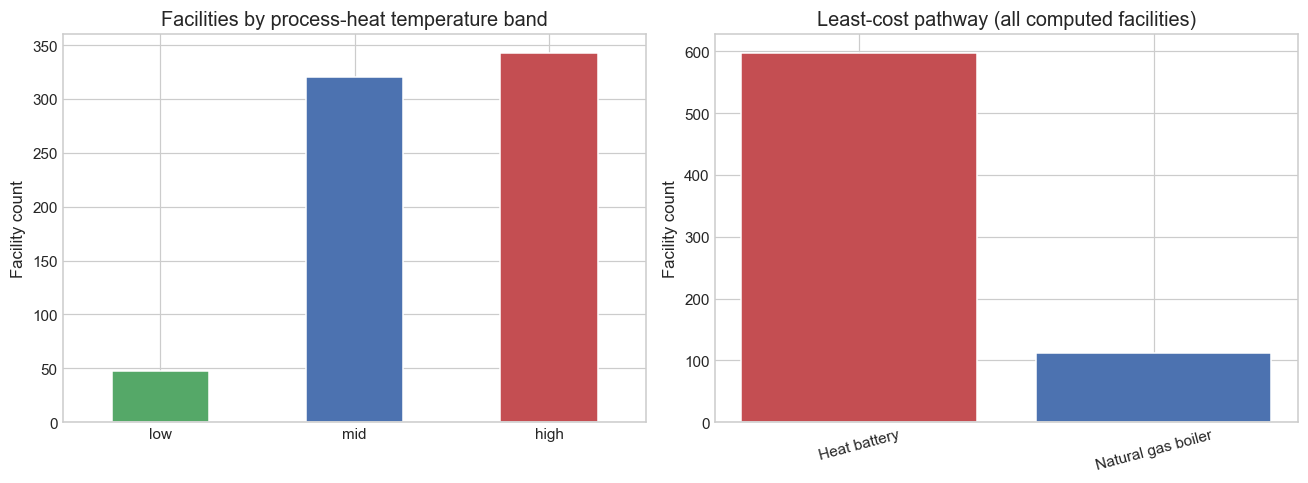

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

temp_counts = df["process_heat_temp_band"].value_counts().reindex(["low", "mid", "high"])
temp_counts.plot(kind="bar", ax=axes[0], color=["#55A868", "#4C72B0", "#C44E52"], edgecolor="white")
axes[0].set_title("Facilities by process-heat temperature band")
axes[0].set_xlabel("")
axes[0].set_ylabel("Facility count")
axes[0].tick_params(axis="x", rotation=0)

lc_counts = df["least_cost_pathway"].value_counts()
lc_counts.index = [PATHWAY_LABELS.get(x, x) for x in lc_counts.index]
colors = [PATHWAY_COLORS.get(k, "gray") for k in df["least_cost_pathway"].value_counts().index]
axes[1].bar(lc_counts.index, lc_counts.values, color=colors, edgecolor="white")
axes[1].set_title("Least-cost pathway (all computed facilities)")
axes[1].set_ylabel("Facility count")
axes[1].tick_params(axis="x", rotation=15)


print(lc_counts)
plt.tight_layout()
plt.show()

## 2. Regional (country) summaries

Aggregated by ISO3 country code. Heat-demand-weighted means show the economics for the bulk of industrial heat in each country.

In [5]:
def weighted_mean(series, weights):
    mask = series.notna() & weights.notna() & (weights > 0)
    if mask.sum() == 0:
        return np.nan
    return np.average(series[mask], weights=weights[mask])


def country_summary(data):
    rows = []
    for iso, grp in data.groupby("iso3_country"):
        w_grp = grp["annual_heat_demand_MWh_th"]
        row = {
            "iso3_country": iso,
            "country_name": grp["eprtr_country"].mode().iloc[0],
            "n_facilities": len(grp),
            "heat_demand_TWh_th": w_grp.sum() / 1e6,
            "elec_hb_price_mean": grp[ELEC_HB_COL].mean(),
            "elec_hp_price_mean": grp[ELEC_HP_COL].mean(),
            "gas_price_mean": grp["gas_price_used_EUR_MWh"].mean(),
            "elec_hb_gas_ratio_mean": grp["elec_hb_gas_ratio"].mean(),
            "elec_hp_gas_ratio_mean": grp["elec_hp_gas_ratio"].mean(),
            "lcoh_gas_mean": grp["lcoh_natural_gas_EUR_MWhth"].mean(),
            "lcoh_hb_mean": grp["lcoh_heat_battery_EUR_MWhth"].mean(),
            "lcoh_hp_mean": grp["lcoh_heat_pump_EUR_MWhth"].mean(),
            "lcoh_gas_wtd": weighted_mean(grp["lcoh_natural_gas_EUR_MWhth"], w_grp),
            "lcoh_hb_wtd": weighted_mean(grp["lcoh_heat_battery_EUR_MWhth"], w_grp),
            "lcoh_hp_wtd": weighted_mean(grp["lcoh_heat_pump_EUR_MWhth"], w_grp),
            "n_hp_eligible": grp["lcoh_heat_pump_EUR_MWhth"].notna().sum(),
            "pct_least_cost_gas": (grp["least_cost_pathway"] == "natural_gas").mean() * 100,
            "pct_least_cost_hp": (grp["least_cost_pathway"] == "heat_pump").mean() * 100,
            "pct_least_cost_hb": (grp["least_cost_pathway"] == "heat_battery").mean() * 100,
        }
        rows.append(row)
    out = pd.DataFrame(rows).sort_values("heat_demand_TWh_th", ascending=False)
    return out


country_df = country_summary(df)
country_df.round(2)

,iso3_country,country_name,n_facilities,heat_demand_TWh_th,elec_hb_price_mean,elec_hp_price_mean,gas_price_mean,elec_hb_gas_ratio_mean,elec_hp_gas_ratio_mean,lcoh_gas_mean,lcoh_hb_mean,lcoh_hp_mean,lcoh_gas_wtd,lcoh_hb_wtd,lcoh_hp_wtd,n_hp_eligible,pct_least_cost_gas,pct_least_cost_hp,pct_least_cost_hb
5,DEU,Germany,174,101.65,41.16,143.43,63.79,0.72,2.52,82.41,47.89,71.67,82.37,47.89,71.67,10,17.82,0.0,82.18
7,ESP,Spain,41,73.00,31.31,132.76,51.36,0.67,2.83,69.55,36.95,67.86,94.76,36.95,67.86,1,2.44,0.0,97.56
11,GBR,United Kingdom,48,44.56,46.95,147.58,31.09,1.52,4.78,40.21,54.32,73.15,39.63,54.32,73.15,4,100.00,0.0,0.00
10,FRA,France,94,38.10,39.10,140.55,69.62,0.60,2.16,90.53,45.59,70.64,95.43,45.59,70.64,15,1.06,0.0,98.94
16,ITA,Italy,43,30.12,33.13,134.58,57.97,0.61,2.49,76.21,38.96,68.51,71.18,38.96,68.51,2,4.65,0.0,95.35
19,POL,Poland,41,24.50,38.33,139.78,74.77,0.56,2.04,96.60,44.74,NaN,99.06,44.74,NaN,0,7.32,0.0,92.68
18,NLD,Netherlands,46,21.16,38.33,139.78,54.15,0.79,2.88,68.80,44.74,70.36,77.62,44.74,70.36,5,4.35,0.0,95.65
20,PRT,Portugal,15,18.69,38.33,139.78,44.42,0.95,3.45,59.80,44.74,NaN,60.79,44.74,NaN,0,26.67,0.0,73.33
24,SWE,Sweden,42,18.51,38.33,139.78,114.50,0.34,1.25,141.44,44.74,NaN,143.07,44.74,NaN,0,0.00,0.0,100.00
0,AUT,Austria,19,16.44,38.33,139.78,59.99,0.66,2.41,79.01,44.74,70.36,77.76,44.74,70.36,1,5.26,0.0,94.74


In [6]:
display_cols = [
    "iso3_country", "country_name", "n_facilities", "heat_demand_TWh_th",
    "elec_hb_price_mean", "elec_hp_price_mean", "gas_price_mean",
    "elec_hb_gas_ratio_mean", "elec_hp_gas_ratio_mean",
    "lcoh_gas_wtd", "lcoh_hb_wtd", "lcoh_hp_wtd",
    "pct_least_cost_gas", "pct_least_cost_hp", "pct_least_cost_hb",
]
country_display = country_df[display_cols].copy()
country_display.columns = [
    "ISO3", "Country", "N facilities", "Heat demand (TWh_th)",
    "HB elec (EUR/MWh)", "HP elec (EUR/MWh)", "Gas (EUR/MWh)",
    "HB elec/gas", "HP elec/gas",
    "LCOH gas (wtd)", "LCOH HB (wtd)", "LCOH HP (wtd)",
    "% least-cost gas", "% least-cost HP", "% least-cost HB",
]
country_display.round(1)

,ISO3,Country,N facilities,Heat demand (TWh_th),HB elec (EUR/MWh),HP elec (EUR/MWh),Gas (EUR/MWh),HB elec/gas,HP elec/gas,LCOH gas (wtd),LCOH HB (wtd),LCOH HP (wtd),% least-cost gas,% least-cost HP,% least-cost HB
5,DEU,Germany,174,101.7,41.2,143.4,63.8,0.7,2.5,82.4,47.9,71.7,17.8,0.0,82.2
7,ESP,Spain,41,73.0,31.3,132.8,51.4,0.7,2.8,94.8,36.9,67.9,2.4,0.0,97.6
11,GBR,United Kingdom,48,44.6,47.0,147.6,31.1,1.5,4.8,39.6,54.3,73.2,100.0,0.0,0.0
10,FRA,France,94,38.1,39.1,140.5,69.6,0.6,2.2,95.4,45.6,70.6,1.1,0.0,98.9
16,ITA,Italy,43,30.1,33.1,134.6,58.0,0.6,2.5,71.2,39.0,68.5,4.7,0.0,95.3
19,POL,Poland,41,24.5,38.3,139.8,74.8,0.6,2.0,99.1,44.7,NaN,7.3,0.0,92.7
18,NLD,Netherlands,46,21.2,38.3,139.8,54.2,0.8,2.9,77.6,44.7,70.4,4.3,0.0,95.7
20,PRT,Portugal,15,18.7,38.3,139.8,44.4,0.9,3.4,60.8,44.7,NaN,26.7,0.0,73.3
24,SWE,Sweden,42,18.5,38.3,139.8,114.5,0.3,1.2,143.1,44.7,NaN,0.0,0.0,100.0
0,AUT,Austria,19,16.4,38.3,139.8,60.0,0.7,2.4,77.8,44.7,70.4,5.3,0.0,94.7


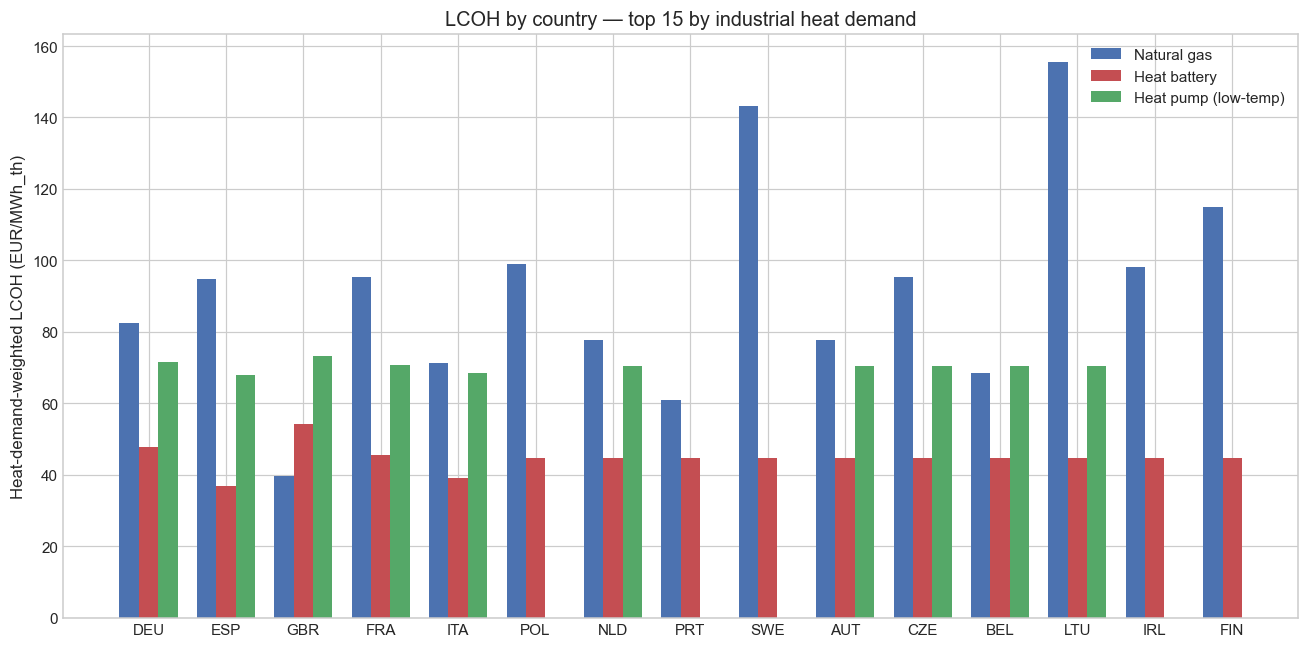

In [7]:
top_countries = country_df.nlargest(15, "heat_demand_TWh_th")

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(top_countries))
width = 0.25

ax.bar(x - width, top_countries["lcoh_gas_wtd"], width, label="Natural gas", color=PATHWAY_COLORS["natural_gas"])
ax.bar(x, top_countries["lcoh_hb_wtd"], width, label="Heat battery", color=PATHWAY_COLORS["heat_battery"])
ax.bar(x + width, top_countries["lcoh_hp_wtd"], width, label="Heat pump (low-temp)", color=PATHWAY_COLORS["heat_pump"])

ax.set_xticks(x)
ax.set_xticklabels(top_countries["iso3_country"])
ax.set_ylabel("Heat-demand-weighted LCOH (EUR/MWh_th)")
ax.set_title("LCOH by country — top 15 by industrial heat demand")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

## 3. Electricity vs natural gas prices

Input energy prices before technology conversion.
- **Heat battery electricity** (`elec_price_hb_EUR_MWh`): BNEF PV fixed-axis LCOE only (no BESS)
- **Heat pump electricity** (`elec_price_hp_EUR_MWh`): BNEF PV + 4h BESS LCOE
- **Gas** (`gas_price_used_EUR_MWh`): Eurostat nrg_pc_203, Band I3, GCV→LHV adjusted

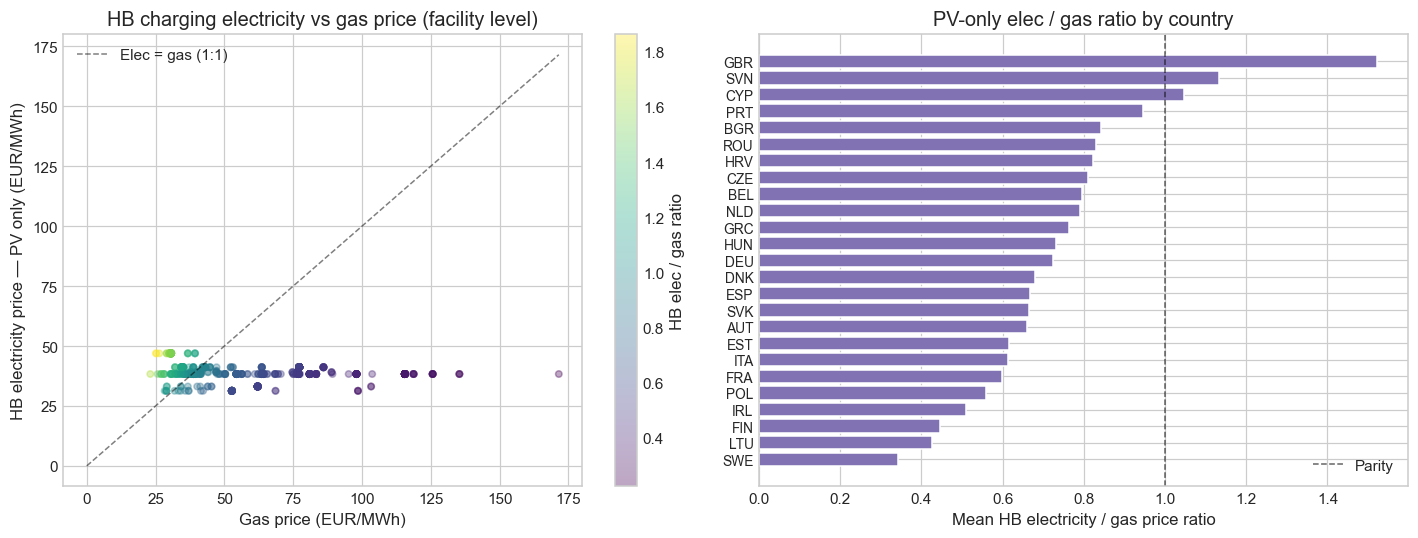

HB elec/gas ratio — mean: 0.72, median: 0.53
HP elec/gas ratio — mean: 2.56, median: 2.17


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: HB charging electricity (PV-only) vs gas — shows the off-grid storage premium
sc = axes[0].scatter(
    df["gas_price_used_EUR_MWh"],
    df[ELEC_HB_COL],
    alpha=0.35, s=18, c=df["elec_hb_gas_ratio"], cmap="viridis",
)
max_p = max(df[ELEC_HB_COL].max(), df["gas_price_used_EUR_MWh"].max())
axes[0].plot([0, max_p], [0, max_p], "k--", lw=1, alpha=0.5, label="Elec = gas (1:1)")
axes[0].set_xlabel("Gas price (EUR/MWh)")
axes[0].set_ylabel("HB electricity price — PV only (EUR/MWh)")
axes[0].set_title("HB charging electricity vs gas price (facility level)")
axes[0].legend()
plt.colorbar(sc, ax=axes[0], label="HB elec / gas ratio")

# Right: elec/gas ratio by country (HB price, PV only)
country_hb_ratio = (
    df.groupby("iso3_country")["elec_hb_gas_ratio"].mean()
    .sort_values(ascending=False)
)
y_pos = np.arange(len(country_hb_ratio))
axes[1].barh(y_pos, country_hb_ratio.values, color="#8172B3", edgecolor="white")
axes[1].axvline(1.0, color="k", ls="--", lw=1, alpha=0.6, label="Parity")
axes[1].set_yticks(y_pos)
axes[1].set_yticklabels(country_hb_ratio.index, fontsize=9)
axes[1].invert_yaxis()
axes[1].set_xlabel("Mean HB electricity / gas price ratio")
axes[1].set_title("PV-only elec / gas ratio by country")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"HB elec/gas ratio — mean: {df['elec_hb_gas_ratio'].mean():.2f}, "
      f"median: {df['elec_hb_gas_ratio'].median():.2f}")
print(f"HP elec/gas ratio — mean: {df['elec_hp_gas_ratio'].mean():.2f}, "
      f"median: {df['elec_hp_gas_ratio'].median():.2f}")

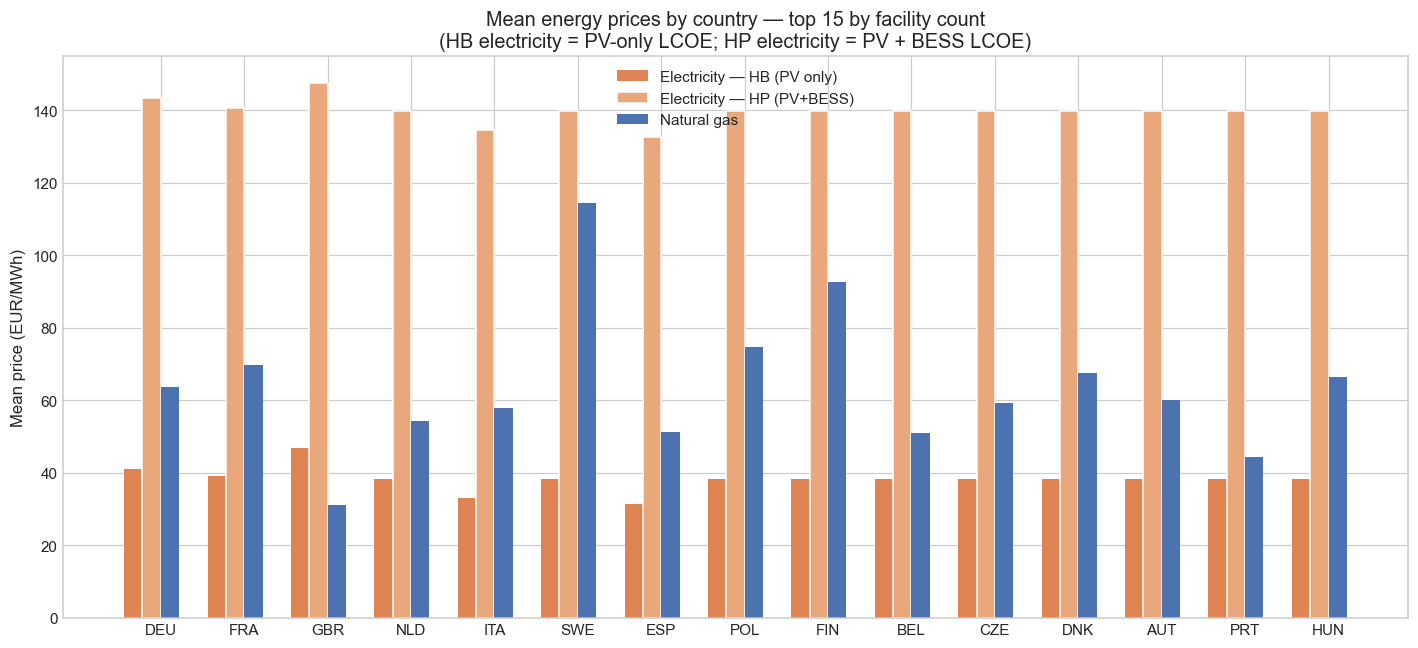

In [9]:
top15 = country_df.nlargest(15, "n_facilities")

# Add per-country HB and HP mean electricity prices to country_df
elec_hb_by_country = df.groupby("iso3_country")[ELEC_HB_COL].mean().rename("elec_hb_mean")
elec_hp_by_country = df.groupby("iso3_country")[ELEC_HP_COL].mean().rename("elec_hp_mean")
top15 = top15.join(elec_hb_by_country, on="iso3_country").join(elec_hp_by_country, on="iso3_country")

fig, ax = plt.subplots(figsize=(13, 6))
x = np.arange(len(top15))
width = 0.22

ax.bar(x - width*1.5, top15["elec_hb_mean"],  width, label="Electricity — HB (PV only)",   color="#DD8452")
ax.bar(x - width*0.5, top15["elec_hp_mean"],  width, label="Electricity — HP (PV+BESS)",   color="#E8A87C", edgecolor="white")
ax.bar(x + width*0.5, top15["gas_price_mean"], width, label="Natural gas",                  color="#4C72B0")

ax.set_xticks(x)
ax.set_xticklabels(top15["iso3_country"])
ax.set_ylabel("Mean price (EUR/MWh)")
ax.set_title("Mean energy prices by country — top 15 by facility count\n"
             "(HB electricity = PV-only LCOE; HP electricity = PV + BESS LCOE)")
ax.legend()
plt.tight_layout()
plt.show()

## 4. LCOH comparison — heat pump, heat battery, natural gas

Levelized cost of heat includes annualized CAPEX, O&M, energy, and carbon costs. Heat pumps are only eligible for low-temperature processes (≤120 °C).

/var/folders/7b/k9t7lbq9461cdn3czk_fmvxm0000gn/T/ipykernel_25822/1090281274.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=lcoh_long, x="pathway_label", y="lcoh_EUR_MWhth", order=order, palette=palette, ax=ax)


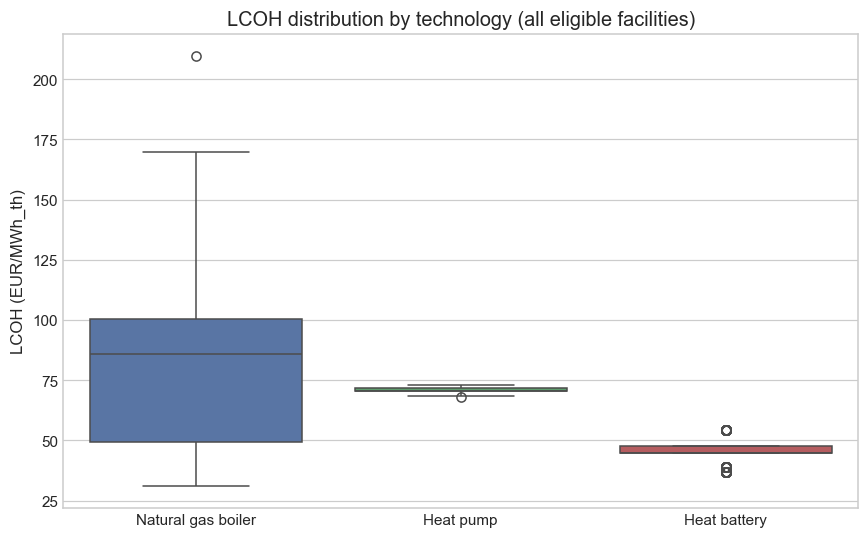

In [10]:
lcoh_long = df.melt(
    id_vars=["eprtr_facility_id", "iso3_country", "process_heat_temp_band", "least_cost_pathway"],
    value_vars=list(LCOH_COLS.values()),
    var_name="pathway_col",
    value_name="lcoh_EUR_MWhth",
).dropna(subset=["lcoh_EUR_MWhth"])

col_to_pathway = {v: k for k, v in LCOH_COLS.items()}
lcoh_long["pathway"] = lcoh_long["pathway_col"].map(col_to_pathway)
lcoh_long["pathway_label"] = lcoh_long["pathway"].map(PATHWAY_LABELS)

fig, ax = plt.subplots(figsize=(8, 5))
order = [PATHWAY_LABELS["natural_gas"], PATHWAY_LABELS["heat_pump"], PATHWAY_LABELS["heat_battery"]]
palette = [PATHWAY_COLORS["natural_gas"], PATHWAY_COLORS["heat_pump"], PATHWAY_COLORS["heat_battery"]]
sns.boxplot(data=lcoh_long, x="pathway_label", y="lcoh_EUR_MWhth", order=order, palette=palette, ax=ax)
ax.set_xlabel("")
ax.set_ylabel("LCOH (EUR/MWh_th)")
ax.set_title("LCOH distribution by technology (all eligible facilities)")
plt.tight_layout()
plt.show()

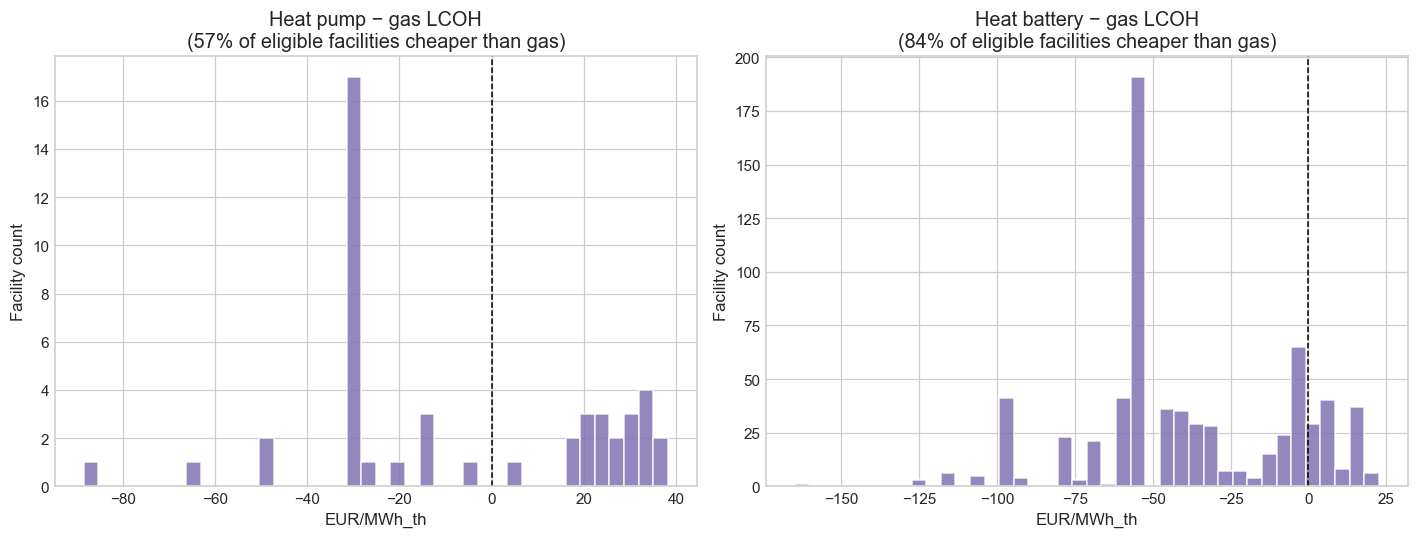

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, col, label in zip(
    axes,
    ["delta_vs_gas_hp_EUR_MWhth", "delta_vs_gas_hb_EUR_MWhth"],
    ["Heat pump − gas LCOH", "Heat battery − gas LCOH"],
):
    subset = df[df[col].notna()]
    ax.hist(subset[col], bins=40, color="#8172B3", edgecolor="white", alpha=0.85)
    ax.axvline(0, color="k", ls="--", lw=1)
    cheaper = (subset[col] < 0).mean() * 100
    ax.set_xlabel("EUR/MWh_th")
    ax.set_ylabel("Facility count")
    ax.set_title(f"{label}\n({cheaper:.0f}% of eligible facilities cheaper than gas)")

plt.tight_layout()
plt.show()

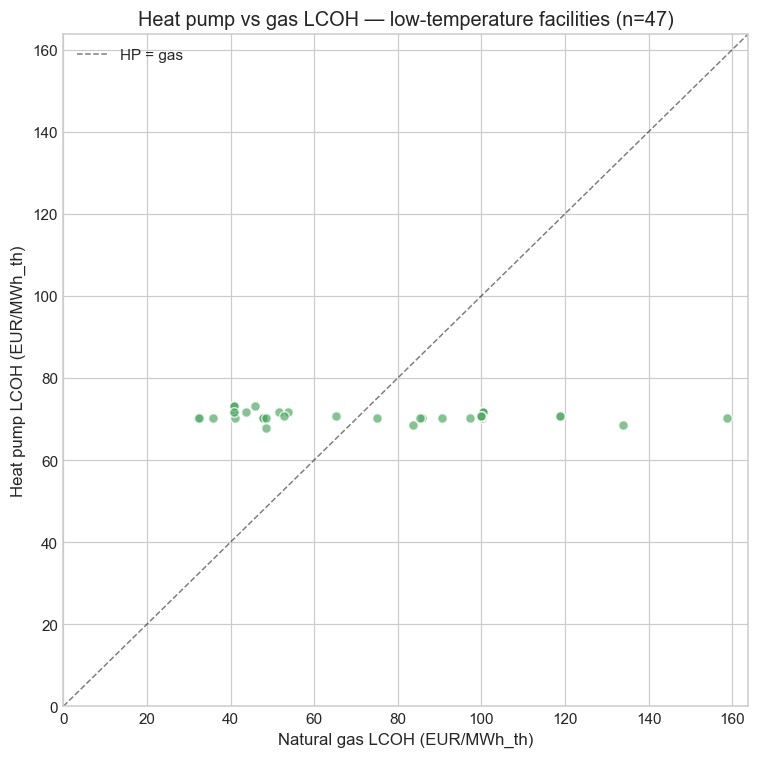

In [12]:
hp_df = df[df["lcoh_heat_pump_EUR_MWhth"].notna()].copy()

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(
    hp_df["lcoh_natural_gas_EUR_MWhth"],
    hp_df["lcoh_heat_pump_EUR_MWhth"],
    alpha=0.7, s=40, c=PATHWAY_COLORS["heat_pump"], edgecolor="white",
)
lim = max(hp_df["lcoh_natural_gas_EUR_MWhth"].max(), hp_df["lcoh_heat_pump_EUR_MWhth"].max()) + 5
ax.plot([0, lim], [0, lim], "k--", lw=1, alpha=0.5, label="HP = gas")
ax.set_xlim(0, lim)
ax.set_ylim(0, lim)
ax.set_xlabel("Natural gas LCOH (EUR/MWh_th)")
ax.set_ylabel("Heat pump LCOH (EUR/MWh_th)")
ax.set_title(f"Heat pump vs gas LCOH — low-temperature facilities (n={len(hp_df)})")
ax.legend()
plt.tight_layout()
plt.show()

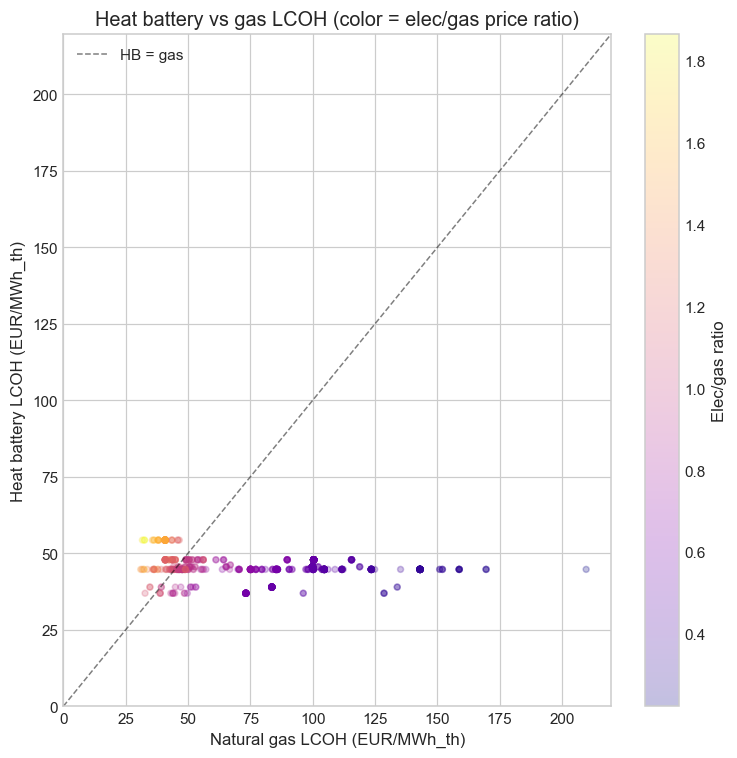

In [13]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(
    df["lcoh_natural_gas_EUR_MWhth"],
    df["lcoh_heat_battery_EUR_MWhth"],
    alpha=0.25, s=15, c=df["elec_gas_ratio"], cmap="plasma",
)
lim = max(df["lcoh_natural_gas_EUR_MWhth"].max(), df["lcoh_heat_battery_EUR_MWhth"].max()) + 10
ax.plot([0, lim], [0, lim], "k--", lw=1, alpha=0.5, label="HB = gas")
ax.set_xlim(0, lim)
ax.set_ylim(0, lim)
ax.set_xlabel("Natural gas LCOH (EUR/MWh_th)")
ax.set_ylabel("Heat battery LCOH (EUR/MWh_th)")
ax.set_title("Heat battery vs gas LCOH (color = elec/gas price ratio)")
cbar = plt.colorbar(ax.collections[0], ax=ax)
cbar.set_label("Elec/gas ratio")
ax.legend()
plt.tight_layout()
plt.show()

## 5. Price drivers — how energy prices relate to LCOH

Electric pathways are more sensitive to electricity prices; gas LCOH tracks gas prices plus carbon.

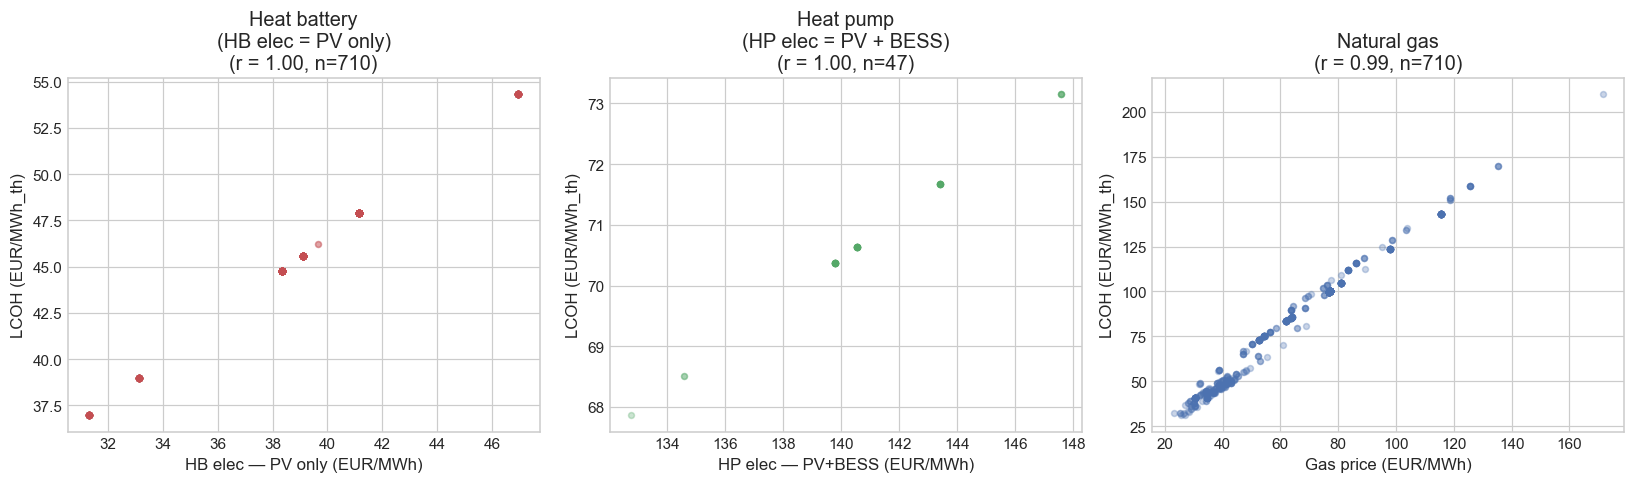

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

pairs = [
    (ELEC_HB_COL,              "lcoh_heat_battery_EUR_MWhth", "Heat battery\n(HB elec = PV only)",  PATHWAY_COLORS["heat_battery"]),
    (ELEC_HP_COL,              "lcoh_heat_pump_EUR_MWhth",    "Heat pump\n(HP elec = PV + BESS)",   PATHWAY_COLORS["heat_pump"]),
    ("gas_price_used_EUR_MWh", "lcoh_natural_gas_EUR_MWhth",  "Natural gas",                        PATHWAY_COLORS["natural_gas"]),
]

for ax, (xcol, ycol, title, color) in zip(axes, pairs):
    sub = df[[xcol, ycol]].dropna()
    ax.scatter(sub[xcol], sub[ycol], alpha=0.3, s=15, c=color)
    r = sub[xcol].corr(sub[ycol])
    xlabel = ("HB elec — PV only (EUR/MWh)" if xcol == ELEC_HB_COL
              else "HP elec — PV+BESS (EUR/MWh)" if xcol == ELEC_HP_COL
              else "Gas price (EUR/MWh)")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("LCOH (EUR/MWh_th)")
    ax.set_title(f"{title}\n(r = {r:.2f}, n={len(sub):,})")

plt.tight_layout()
plt.show()

## 6. Least-cost pathway by country and temperature band

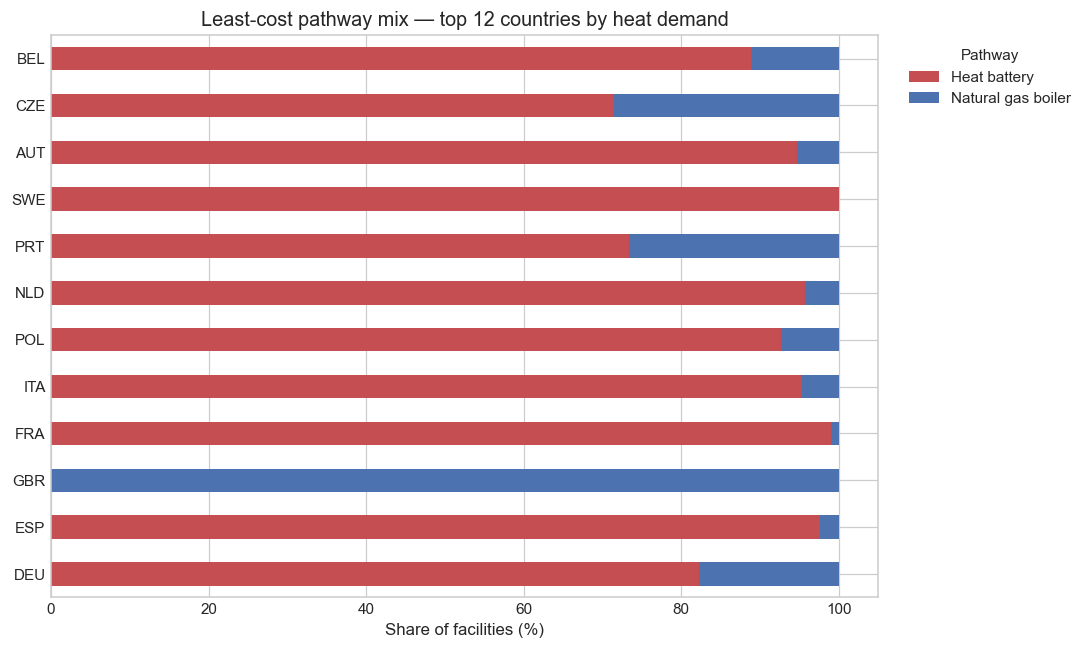

In [15]:
top12 = country_df.nlargest(12, "heat_demand_TWh_th")["iso3_country"]
lc_pivot = (
    df[df["iso3_country"].isin(top12)]
    .groupby(["iso3_country", "least_cost_pathway"])
    .size()
    .unstack(fill_value=0)
    .reindex(top12)
)
lc_pct = lc_pivot.div(lc_pivot.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(10, 6))
lc_pct.plot(kind="barh", stacked=True, ax=ax,
            color=[PATHWAY_COLORS.get(c, "gray") for c in lc_pct.columns])
ax.set_xlabel("Share of facilities (%)")
ax.set_ylabel("")
ax.set_title("Least-cost pathway mix — top 12 countries by heat demand")
ax.legend(title="Pathway", labels=[PATHWAY_LABELS.get(c, c) for c in lc_pct.columns], bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()

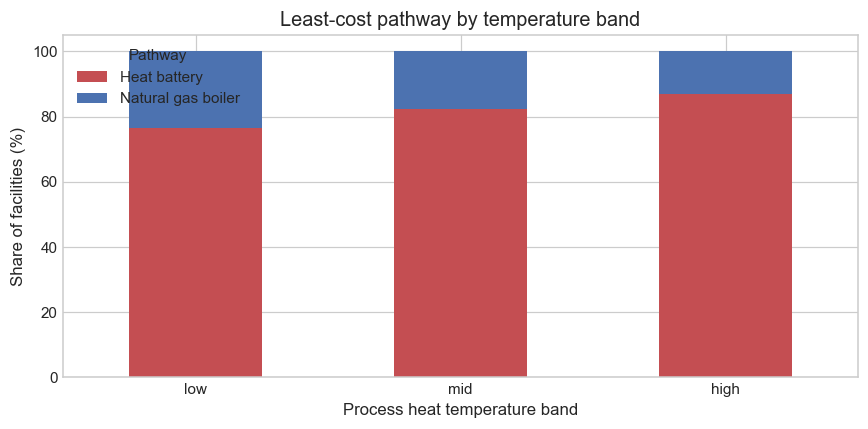

In [16]:
band_lc = (
    df.groupby(["process_heat_temp_band", "least_cost_pathway"])
    .size()
    .unstack(fill_value=0)
    .reindex(["low", "mid", "high"])
)
band_pct = band_lc.div(band_lc.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(8, 4))
band_pct.plot(kind="bar", stacked=True, ax=ax,
              color=[PATHWAY_COLORS.get(c, "gray") for c in band_pct.columns])
ax.set_xlabel("Process heat temperature band")
ax.set_ylabel("Share of facilities (%)")
ax.set_title("Least-cost pathway by temperature band")
ax.legend(title="Pathway", labels=[PATHWAY_LABELS.get(c, c) for c in band_pct.columns])
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

## 7. Facility map — LCOH by location

Interactive map of facilities in the **analysis cohort** (LCP-matched, excluding `1(c)`). **Click a marker** for a per-facility breakdown. **Hover** for a quick summary.

- **Colour** = least-cost pathway (blue = gas, green = heat pump, red = heat battery)
- **Circle size** ∝ log(annual heat demand)
- **Saved to** `outputs/maps/lcoh_facility_map_offgrid_lcp_matched_excl_1c_<N>fac_<date>.html` when you run the cell below
- Requires `folium` (`pip install folium`)


In [17]:

# ── Filter to the 115-facility subset (id_direct, non-1c, co2_year 2024) ─────
map_df = df[
    (df["match_method"] == "id_direct") &
    (df["analysis_year"] == 2024)
].copy()

map_df["eprtr_lat"] = pd.to_numeric(map_df["eprtr_lat"], errors="coerce")
map_df["eprtr_lon"] = pd.to_numeric(map_df["eprtr_lon"], errors="coerce")
map_df = map_df.dropna(subset=["eprtr_lat", "eprtr_lon", "lcoh_natural_gas_EUR_MWhth"])

# ── Join solar feasibility data ───────────────────────────────────────────────
SF_PATH = ROOT / "outputs" / "solar_feasibility_115.csv"
SF_NUMERIC_COLS = [
    "pvgis_annual_cf", "pvgis_kwh_per_kwp",
    "site_pv_lcoe_eur_mwh", "lcoh_hb_site_specific_eur_mwhth",
    "land_needed_km2", "suitable_land_km2", "land_surplus_deficit_km2",
    "suitable_land_adj_km2", "land_surplus_deficit_adj_km2",
    "overlap_n_neighbours", "overlap_area_total_km2",
]
SF_STR_COLS = ["land_feasibility", "land_feasibility_adj"]

if SF_PATH.exists():
    sf = pd.read_csv(SF_PATH, usecols=["source_id"] + SF_NUMERIC_COLS + SF_STR_COLS)
    for col in SF_NUMERIC_COLS:
        sf[col] = pd.to_numeric(sf[col], errors="coerce")
    # land_feasibility columns stay as strings — do NOT coerce to numeric
    map_df = map_df.merge(sf, left_on="eprtr_facility_id", right_on="source_id", how="left")
else:
    for col in SF_NUMERIC_COLS:
        map_df[col] = float("nan")
    map_df["land_feasibility"]     = "NOT_AVAILABLE"
    map_df["land_feasibility_adj"] = "NOT_AVAILABLE"

LAND_COLORS = {
    "FEASIBLE":   "#2ca02c",
    "INFEASIBLE": "#d62728",
}

def marker_radius(mwh_th):
    if pd.isna(mwh_th) or mwh_th <= 0:
        return 4
    return min(18, max(4, 3.0 * math.log10(mwh_th) - 5))

def fmt(val, decimals=1, suffix=""):
    return "—" if pd.isna(val) else f"{val:,.{decimals}f}{suffix}"

def land_badge(feasibility):
    color = LAND_COLORS.get(str(feasibility), "#888")
    return f'<span style="background:{color};color:white;padding:1px 6px;border-radius:3px;font-size:11px">{feasibility}</span>'

def build_popup(row):
    lc     = row.get("least_cost_pathway", "")
    lc_lbl = PATHWAY_LABELS.get(lc, lc)
    lc_clr = PATHWAY_COLORS.get(lc, "#888")

    gas_l = fmt(row["lcoh_natural_gas_EUR_MWhth"])
    hb_l  = fmt(row["lcoh_heat_battery_EUR_MWhth"])
    hp_l  = (fmt(row["lcoh_heat_pump_EUR_MWhth"])
             if pd.notna(row.get("lcoh_heat_pump_EUR_MWhth"))
             else "N/A — temp. ineligible")

    d_hb = (f'<span style="color:#888">Δ {fmt(row["delta_vs_gas_hb_EUR_MWhth"], suffix=" EUR/MWh_th")}</span>'
            if pd.notna(row.get("delta_vs_gas_hb_EUR_MWhth")) else "")
    d_hp = (f'<span style="color:#888">Δ {fmt(row["delta_vs_gas_hp_EUR_MWhth"], suffix=" EUR/MWh_th")}</span>'
            if pd.notna(row.get("delta_vs_gas_hp_EUR_MWhth")) else "")

    elec_hb_val = fmt(row.get(ELEC_HB_COL))
    elec_hp_val = fmt(row.get(ELEC_HP_COL))
    gas_p       = fmt(row.get("gas_price_used_EUR_MWh"))

    temp_c     = (fmt(row["process_heat_temp_C"], decimals=0, suffix=" °C")
                  if pd.notna(row.get("process_heat_temp_C")) else "not reported")
    heat_gw    = fmt(row["annual_heat_demand_MWh_th"] / 1000, decimals=1, suffix=" GWh_th/yr")
    provenance = row.get("annual_heat_demand_provenance", "—")
    confidence = row.get("lcoh_confidence", "—")
    flags_raw  = str(row.get("flags") or "none")
    flags_disp = flags_raw[:150] + ("…" if len(flags_raw) > 150 else "")
    excl       = str(row.get("pathways_excluded") or "none")

    cf_str        = fmt(row.get("pvgis_annual_cf"), decimals=3)
    site_lcoe_str = fmt(row.get("site_pv_lcoe_eur_mwh"), suffix=" EUR/MWh_e")
    site_hb_str   = fmt(row.get("lcoh_hb_site_specific_eur_mwhth"), suffix=" EUR/MWh_th")
    land_needed   = fmt(row.get("land_needed_km2"), suffix=" km²")
    suitable      = fmt(row.get("suitable_land_km2"), suffix=" km²")
    surplus       = fmt(row.get("land_surplus_deficit_km2"), suffix=" km²")
    feas          = str(row.get("land_feasibility", "—"))
    suitable_adj  = fmt(row.get("suitable_land_adj_km2"), suffix=" km²")
    surplus_adj   = fmt(row.get("land_surplus_deficit_adj_km2"), suffix=" km²")
    feas_adj      = str(row.get("land_feasibility_adj", "—"))
    n_nbrs        = int(row["overlap_n_neighbours"]) if pd.notna(row.get("overlap_n_neighbours")) else 0
    ov_area       = fmt(row.get("overlap_area_total_km2"), decimals=2, suffix=" km²")

    return f"""
<div style="font-family:sans-serif;font-size:12px;width:360px;line-height:1.55">
<b style="font-size:13px">{row['eprtr_facility_name']}</b><br>
<span style="color:#666">{row['eprtr_country']} &nbsp;·&nbsp; activity {row['eprtr_activity']} &nbsp;·&nbsp; {int(row['analysis_year'])}</span>
<hr style="margin:5px 0">

<b>Heat demand:</b> {heat_gw} <span style="color:#888;font-size:11px">({provenance})</span><br>
<b>Temp band:</b> {row['process_heat_temp_band']} ({temp_c})
&nbsp;·&nbsp; <span style="color:#888;font-size:11px">{row.get('temp_provenance','—')}</span><br>
<span style="color:#888;font-size:11px">Excluded: {excl}</span>
<hr style="margin:5px 0">

<b>LCOH (EUR/MWh_th):</b>
<table style="border-collapse:collapse;width:100%;margin-top:3px">
<tr><td width="48%">Natural gas:</td><td><b>{gas_l}</b></td><td></td></tr>
<tr><td>Heat battery (BNEF):</td><td><b>{hb_l}</b></td><td>{d_hb}</td></tr>
<tr><td>Heat pump:</td><td><b>{hp_l}</b></td><td>{d_hp}</td></tr>
</table>
<b>Least-cost:</b> <span style="color:{lc_clr};font-weight:bold">{lc_lbl}</span>
<hr style="margin:5px 0">

<b>Site-specific solar (PVGIS ERA5 2023):</b><br>
&nbsp;Capacity factor: {cf_str} &nbsp;·&nbsp; LCOE: {site_lcoe_str}<br>
&nbsp;HB LCOH (site-specific): <b>{site_hb_str}</b>
<hr style="margin:5px 0">

<b>Land feasibility (10 km, unadjusted):</b> {land_badge(feas)}<br>
&nbsp;Land needed: {land_needed} &nbsp;·&nbsp; Suitable: {suitable} &nbsp;·&nbsp; Surplus/deficit: {surplus}<br>
<b>Land feasibility (overlap-adjusted, Option B):</b> {land_badge(feas_adj)}<br>
&nbsp;Suitable (adj): {suitable_adj} &nbsp;·&nbsp; Surplus/deficit (adj): {surplus_adj}<br>
<span style="color:#888;font-size:11px">Overlapping neighbours: {n_nbrs} &nbsp;·&nbsp; Total overlap area: {ov_area}</span>
<hr style="margin:5px 0">

<b>Prices used:</b><br>
&nbsp;HB electricity (PV only): {elec_hb_val} EUR/MWh &nbsp;·&nbsp;
HP (PV+BESS): {elec_hp_val} EUR/MWh &nbsp;·&nbsp;
Gas: {gas_p} EUR/MWh
<hr style="margin:5px 0">

<b>Confidence:</b> {confidence} &nbsp;·&nbsp; <b>Status:</b> {row.get('verification_status','—')}<br>
<span style="color:#888;font-size:11px"><b>Flags:</b> {flags_disp}</span>
</div>"""

# ── Build map (ring colour = overlap-adjusted feasibility) ────────────────────
m = folium.Map(location=[45.0, 5.0], zoom_start=5, tiles="CartoDB positron")

for _, row in map_df.iterrows():
    color      = PATHWAY_COLORS.get(row.get("least_cost_pathway"), "#888888")
    radius     = marker_radius(row["annual_heat_demand_MWh_th"])
    lc_lbl     = PATHWAY_LABELS.get(row.get("least_cost_pathway"), row.get("least_cost_pathway", ""))
    feas_adj   = str(row.get("land_feasibility_adj", ""))
    ring_color = LAND_COLORS.get(feas_adj, "#aaaaaa")

    folium.CircleMarker(
        location=[row["eprtr_lat"], row["eprtr_lon"]],
        radius=radius,
        color=ring_color,
        fill=True,
        fill_color=color,
        fill_opacity=0.80,
        weight=2.5,
        popup=folium.Popup(build_popup(row), max_width=380),
        tooltip=folium.Tooltip(
            f"<b>{row['eprtr_facility_name']}</b><br>"
            f"{row['eprtr_country']} · {row['process_heat_temp_band']} band<br>"
            f"Gas: {fmt(row['lcoh_natural_gas_EUR_MWhth'])} | "
            f"HB (BNEF): {fmt(row['lcoh_heat_battery_EUR_MWhth'])} | "
            f"HB (site): {fmt(row.get('lcoh_hb_site_specific_eur_mwhth'))} EUR/MWh_th<br>"
            f"Least-cost: <b>{lc_lbl}</b> · Land (adj): <b>{feas_adj}</b>",
            sticky=False,
        ),
    ).add_to(m)

# ── Legend ────────────────────────────────────────────────────────────────────
legend_html = """
<div style="position:fixed;bottom:40px;left:40px;z-index:1000;
            background:white;padding:12px 16px;border-radius:8px;
            border:1px solid #ccc;font-family:sans-serif;font-size:12px;line-height:1.9">
    <b>Fill — Least-cost pathway</b><br>
    <span style="color:#4C72B0;font-size:16px">&#9679;</span> Natural gas boiler<br>
    <span style="color:#55A868;font-size:16px">&#9679;</span> Heat pump<br>
    <span style="color:#C44E52;font-size:16px">&#9679;</span> Heat battery (BNEF)<br>
    <hr style="margin:5px 0">
    <b>Ring — Land feasibility (10 km, overlap-adjusted)</b><br>
    <span style="color:#2ca02c;font-size:16px">&#9679;</span> Feasible<br>
    <span style="color:#d62728;font-size:16px">&#9679;</span> Infeasible<br>
    <span style="color:#aaaaaa;font-size:16px">&#9679;</span> Not computable<br>
    <hr style="margin:5px 0">
    <span style="color:#888;font-size:11px">Size &#8733; log(annual heat demand)<br>
    Click marker for full detail</span>
</div>"""
m.get_root().html.add_child(folium.Element(legend_html))

from datetime import date
MAP_OUT_DIR = ROOT / "outputs" / "maps"
MAP_OUT_DIR.mkdir(parents=True, exist_ok=True)
map_filename = f"lcoh_facility_map_offgrid_idirect_2024_{len(map_df)}fac_{date.today().isoformat()}.html"
map_path = MAP_OUT_DIR / map_filename
m.save(str(map_path))

# Summary counts
n_feasible       = (map_df["land_feasibility"]     == "FEASIBLE").sum()
n_infeasible     = (map_df["land_feasibility"]     == "INFEASIBLE").sum()
n_feasible_adj   = (map_df["land_feasibility_adj"] == "FEASIBLE").sum()
n_infeasible_adj = (map_df["land_feasibility_adj"] == "INFEASIBLE").sum()
n_overlapping    = (map_df["overlap_n_neighbours"] > 0).sum()
print(f"Map: {len(map_df):,} facilities plotted")
print(f"  Land feasibility (unadjusted)    — FEASIBLE: {n_feasible}  INFEASIBLE: {n_infeasible}")
print(f"  Land feasibility (overlap-adj.)  — FEASIBLE: {n_feasible_adj}  INFEASIBLE: {n_infeasible_adj}")
print(f"  Facilities with overlapping neighbours: {n_overlapping}")
print(f"Saved → {map_path.resolve()}")
m


Map: 110 facilities plotted
  Land feasibility (unadjusted)    — FEASIBLE: 85  INFEASIBLE: 25
  Land feasibility (overlap-adj.)  — FEASIBLE: 75  INFEASIBLE: 35
  Facilities with overlapping neighbours: 39
Saved → /Users/annayuen/Desktop/IECC/industrial_decarb/LCOH_EU_workflow/off_grid_electricity_run/outputs/maps/lcoh_facility_map_offgrid_idirect_2024_110fac_2026-06-08.html


## 8. Key takeaways — off-grid electricity scenario

**Cohort:** LCP-matched facilities only (`spatial_nearest` / `id_direct`), excluding E-PRTR activity **`1(c)`**. Re-run all cells above for current counts and charts.

These results use **BNEF off-grid LCOE**, not Eurostat grid industrial tariffs. Gas remains **Eurostat** + EU ETS carbon.

### Least-cost pathway

Run the pathway breakdown cells for this cohort. Under off-grid PV-only HB charging, **heat battery** typically dominates vs **natural gas** among **non-1(c) industrial** sites; **heat pump** rarely wins when PV+BESS is required.

### Electricity pricing

- **Heat battery** — BNEF **PV fixed-axis LCOE only** (HB is the storage device).
- **Heat pump** — BNEF **PV + utility-scale 4h BESS**.
- **Gas** — Eurostat Band I3 (GCV→LHV) + ETS on combustion.

### Why HB LCOH can cluster

Distinct HB electricity/LCOH steps often reflect **one BNEF price per country** (2025/2030 mapping) and **proxied** BNEF tiers for countries without direct LCOE — not continuous site-level variation.

### Caveats

- Excluding **`1(c)`** removes large power/CHP plants; do not compare headline shares directly to the full 1,759-facility run.
- **`no_match`** sites are out of scope here (no LCP fuel attribution).
- Proxied BNEF rows are placeholders — treat cross-country rankings cautiously.
- Compare to **`grid_electricity_run`** for grid-tariff electrification.
